# VP Noise Scheduler Diagnostics

Visual check for large-$T$ behavior of the closed-form forward process:

$$X_t = \alpha_t X_0 + \sigma_t Z,\quad \alpha_t = e^{-\beta t/2},\ \sigma_t=\sqrt{1-e^{-\beta t}},\ Z\sim\mathcal N(0,1).$$

As $t\to\infty$, this converges to $\mathcal N(0,1)$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from implied_volatility_diffusion import VPNoiseScheduler

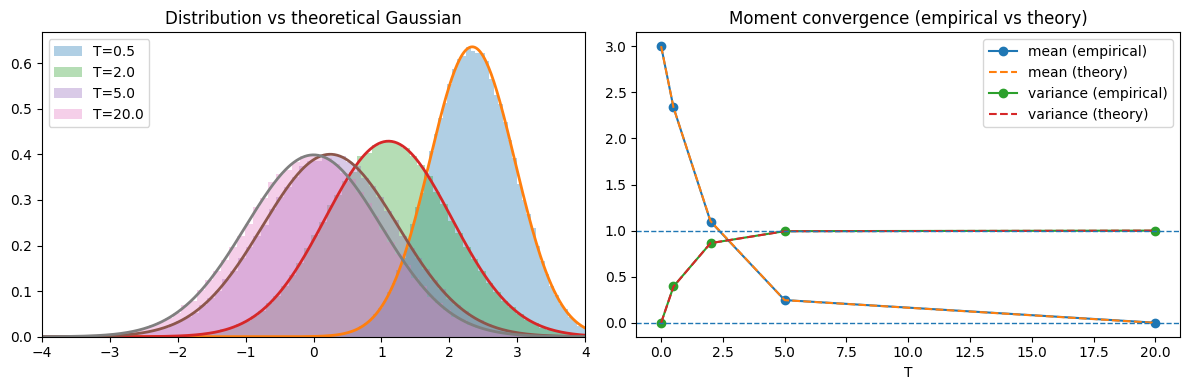

In [ ]:
rng = np.random.default_rng(42)
scheduler = VPNoiseScheduler(beta=1.0)

x0 = np.full(200_000, 3.0)
times = [0.0, 0.5, 2.0, 5.0, 20.0]

means_emp, vars_emp = [], []
means_theory, vars_theory = [], []

samples = {}

for t in times:
    # use independent randomness per t
    xt = scheduler.add_noise(x0, t=t, rng=np.random.default_rng(42 + int(t * 10)))
    samples[t] = xt

    means_emp.append(np.mean(xt))
    vars_emp.append(np.var(xt))

    # theoretical moments (similar to test)
    decay_mean = np.exp(-0.5 * t)
    decay_var = np.exp(-t)

    means_theory.append(decay_mean * 3.0)
    vars_theory.append(decay_var * 0.0 + (1.0 - decay_var))


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
xgrid = np.linspace(-4, 4, 400)

for t in times:
    if t == 0.0:
        continue
    axes[0].hist(samples[t], bins=80, density=True, alpha=0.35, label=f"T={t}")

    # theoretical Gaussian at time t
    mean_t = np.exp(-0.5 * t) * 3.0
    var_t = 1.0 - np.exp(-t)
    std_t = np.sqrt(var_t)

    pdf = (1.0 / (std_t * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xgrid - mean_t) / std_t) ** 2)
    axes[0].plot(xgrid, pdf, linewidth=2)

axes[0].set_title("Distribution vs theoretical Gaussian")
axes[0].set_xlim(-4, 4)
axes[0].legend()

# Moments
axes[1].plot(times, means_emp, marker="o", label="mean (empirical)")
axes[1].plot(times, means_theory, linestyle="--", label="mean (theory)")

axes[1].plot(times, vars_emp, marker="o", label="variance (empirical)")
axes[1].plot(times, vars_theory, linestyle="--", label="variance (theory)")

axes[1].axhline(0.0, linestyle="--", linewidth=1)
axes[1].axhline(1.0, linestyle="--", linewidth=1)

axes[1].set_title("Moment convergence (empirical vs theory)")
axes[1].set_xlabel("T")
axes[1].legend()

plt.tight_layout()
plt.show()

As $t\to\infty$ i.e $t=20$, we can see the distribution moving to a standard normal with 0 mean and variance 1